In [1]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))



Current Working Directory:
c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\classification
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


Training SVM and tuning hyperparameters... This may take a moment.

--- SVM Model Evaluation ---
Best Parameters: {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Accuracy:  0.1900
Precision: 0.2363
Recall:    0.1900
F1 Score:  0.1693

Classification Report:
               precision    recall  f1-score   support

           1       0.19      0.23      0.21       124
           2       0.13      0.15      0.14       101
           3       0.43      0.02      0.04       129
           4       0.22      0.37      0.27       123
           5       0.19      0.18      0.18       123

    accuracy                           0.19       600
   macro avg       0.23      0.19      0.17       600
weighted avg       0.24      0.19      0.17       600



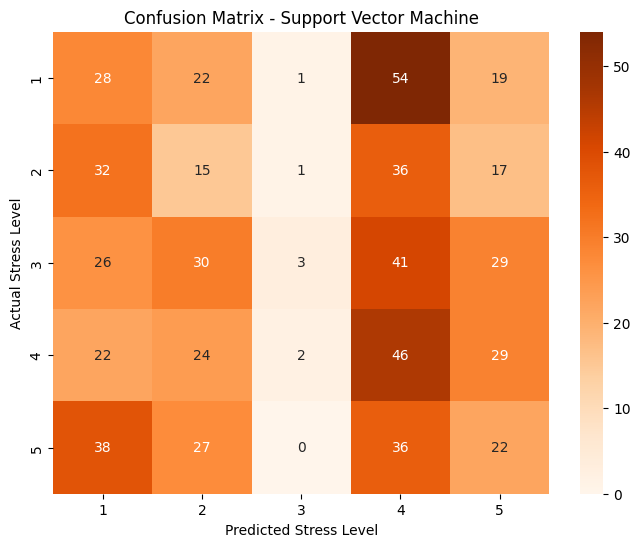

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)


# Ensure this matches your file path, e.g., "data/train.csv"
file_path = "train.csv" 
df = pd.read_csv("data/train.csv")


X = df.drop(columns=['Employee_Id', 'Stress_Level'])
y = df['Stress_Level']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)


categorical_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# CRITICAL FOR SVM: Numerical data MUST be scaled using StandardScaler.
# Categorical data is encoded using OneHotEncoder.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# 6. Create the Model Pipeline
# SVC = Support Vector Classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# ==========================================
# 7. Hyperparameter Tuning 
# ==========================================
# C: Controls the penalty for misclassification (Higher C = stricter boundaries)
# kernel: 'linear' creates straight lines, 'rbf' creates complex curves
# gamma: Determines how far the influence of a single training example reaches
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto'] 
}

print("Training SVM and tuning hyperparameters... This may take a moment.")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# ==========================================
# 8. Make Predictions
# ==========================================
y_pred = best_model.predict(X_test)

# ==========================================
# 9. Evaluation Metrics
# ==========================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print(f"\n--- SVM Model Evaluation ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# 10. Confusion Matrix Visualization
# ==========================================
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Stress Level')
plt.ylabel('Actual Stress Level')
plt.title('Confusion Matrix - Support Vector Machine')
plt.show()

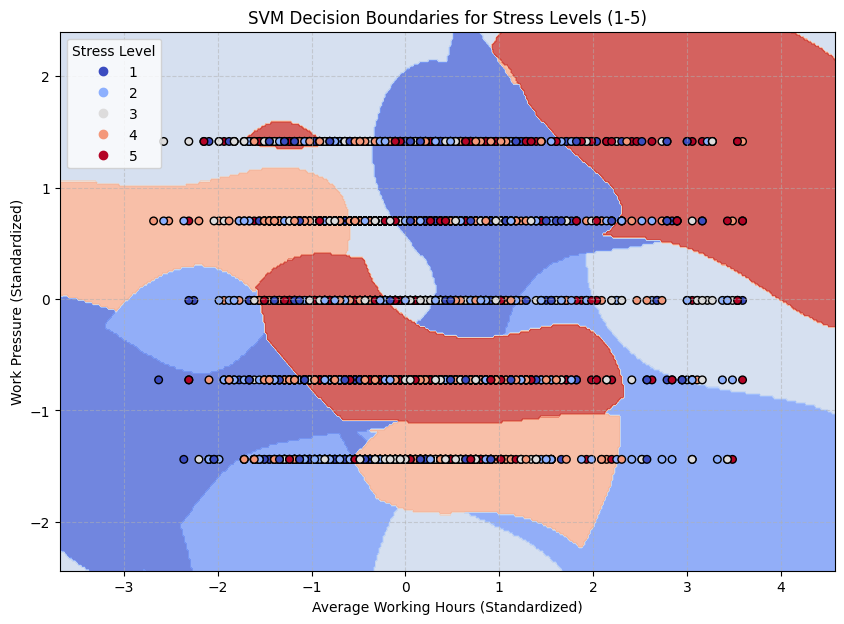

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Load your dataset
df = pd.read_csv('data/train.csv')

# 2. Select two numerical features for 2D visualization
# We use Avg_Working_Hours_Per_Day and Work_Pressure
X = df[['Avg_Working_Hours_Per_Day', 'Work_Pressure']].values
y = df['Stress_Level'].values

# 3. Standardize the features (Critical for SVM performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the SVM model
# Using 'rbf' kernel to visualize complex non-linear boundaries
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_scaled, y)

# 5. Create a mesh grid to plot the decision regions
h = .02  # Step size in the mesh
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 6. Predict classes for every point in the mesh grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 7. Visualization
plt.figure(figsize=(10, 7))

# Plot decision boundaries using filled contours
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

# Plot actual data points
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, 
                      cmap=plt.cm.coolwarm, edgecolors='k', s=30)

plt.xlabel('Average Working Hours (Standardized)')
plt.ylabel('Work Pressure (Standardized)')
plt.title('SVM Decision Boundaries for Stress Levels (1-5)')
plt.legend(*scatter.legend_elements(), title="Stress Level")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()